In [10]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import time

In [11]:
##Load the Preprocessed Dataset
X_train = pd.read_csv("X_train.csv")
y_train = pd.read_csv("y_train.csv")

X_val = pd.read_csv("X_val.csv")
y_val = pd.read_csv("y_val.csv")

X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv")


In [12]:
print(X_train.head(5))
print(y_train.value_counts())

                                               Tweet  \
0  @JustinTrudeau The truth of your evil becomes ...   
1  This cap is from the youngster's initial arres...   
2  "âFreedom Convoyâ organizer Tamara Lich â...   
3  Tamara Lich has been arrested.\n\n#FAFO #Freed...   
4  @JMeanypants While ppl in the Ukraine fight fo...   

                                       Cleaned_Tweet  \
0  the truth of your evil becomes more apparent e...   
1  this cap is from the youngster s initial arres...   
2  freedom convoy organizer tamara rich will be r...   
3   tamara lich has been arrested fafo freedomconvoy   
4  while pal in the ukraine fight for their real ...   

                                 Final_Cleaned_Tweet  
0  truth evil becomes apparent every day american...  
1  cap youngster initial arrest tan pant right ta...  
2  freedom convoy organizer tamara rich return ot...  
3              tamara lich arrest fafo freedomconvoy  
4  pal ukraine fight real freedom convoy forming ..

There is no class imbalance issue

#Changed from 5000 to 4000 to reduce training time 

In [13]:
# Initialize TF-IDF Vectorizer with unigram + bigram
tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 2),        # Unigram + Bigram
    max_features=4000,         # Top 5000 features
    min_df=2,
    smooth_idf=True,           # Apply smoothing to avoid division by zero
    sublinear_tf=True          # Apply logarithmic term frequency scaling
)

In [14]:
print(X_train['Final_Cleaned_Tweet'].isna().sum())
print(X_test['Final_Cleaned_Tweet'].isna().sum())
print(X_val['Final_Cleaned_Tweet'].isna().sum())


9
4
2


In [15]:
#Train
X_train['Final_Cleaned_Tweet'] = X_train['Final_Cleaned_Tweet'].fillna('').astype(str).str.strip()
train_mask = X_train['Final_Cleaned_Tweet'] != ''
X_train = X_train[train_mask]
y_train = y_train[train_mask]
#Val
X_val['Final_Cleaned_Tweet'] = X_val['Final_Cleaned_Tweet'].fillna('').astype(str).str.strip()
val_mask = X_val['Final_Cleaned_Tweet'] != ''
X_val = X_val[val_mask]
y_val = y_val[val_mask]
#Test
X_test['Final_Cleaned_Tweet'] = X_test['Final_Cleaned_Tweet'].fillna('').astype(str).str.strip()
test_mask = X_test['Final_Cleaned_Tweet'] != ''
X_test = X_test[test_mask]
y_test = y_test[test_mask]

In [16]:
# Fit on training data, transform train/val/test sets
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train['Final_Cleaned_Tweet'])
X_val_tfidf = tfidf_vectorizer.transform(X_val['Final_Cleaned_Tweet'])
X_test_tfidf = tfidf_vectorizer.transform(X_test['Final_Cleaned_Tweet'])

# Print shapes to verify
print("Train TF-IDF shape:", X_train_tfidf.shape)
print("Validation TF-IDF shape:", X_val_tfidf.shape)
print("Test TF-IDF shape:", X_test_tfidf.shape)

Train TF-IDF shape: (26896, 4000)
Validation TF-IDF shape: (3998, 4000)
Test TF-IDF shape: (7496, 4000)


In [17]:
import pandas as pd

# Get feature names from the vectorizer
feature_names = tfidf_vectorizer.get_feature_names_out()

# Convert the sparse matrix to a dense format and wrap in a DataFrame
df_tfidf_sample = pd.DataFrame(X_train_tfidf[:5].todense(), columns=feature_names)

# Display the DataFrame
print(df_tfidf_sample)

   1st  2020  2021  2022  2022 freedom  2022 fundraiser  2022 live  \
0  0.0   0.0   0.0   0.0           0.0              0.0        0.0   
1  0.0   0.0   0.0   0.0           0.0              0.0        0.0   
2  0.0   0.0   0.0   0.0           0.0              0.0        0.0   
3  0.0   0.0   0.0   0.0           0.0              0.0        0.0   
4  0.0   0.0   0.0   0.0           0.0              0.0        0.0   

   2022 ottawa  2022 police  2022 protest  ...  york  young  youtube   yr  \
0          0.0          0.0           0.0  ...   0.0    0.0      0.0  0.0   
1          0.0          0.0           0.0  ...   0.0    0.0      0.0  0.0   
2          0.0          0.0           0.0  ...   0.0    0.0      0.0  0.0   
3          0.0          0.0           0.0  ...   0.0    0.0      0.0  0.0   
4          0.0          0.0           0.0  ...   0.0    0.0      0.0  0.0   

   yup   ze  zealand  zero  zone   zu  
0  0.0  0.0      0.0   0.0   0.0  0.0  
1  0.0  0.0      0.0   0.0   0.0  0.

These features are a mixture of unigrams and bigrams — the top 5000 most important ones based on frequency and TF-IDF weight across X_train.

In [18]:
# Reshape for RNN input
num_features = X_train_tfidf.shape[1]
X_train_rnn = X_train_tfidf.toarray().reshape((X_train_tfidf.shape[0], num_features, 1))
X_val_rnn = X_val_tfidf.toarray().reshape((X_val_tfidf.shape[0], num_features, 1))
X_test_rnn = X_test_tfidf.toarray().reshape((X_test_tfidf.shape[0], num_features, 1))

# Encode labels
label_encoder = LabelEncoder()
y_train_enc = to_categorical(label_encoder.fit_transform(y_train))
y_val_enc = to_categorical(label_encoder.transform(y_val))
y_test_enc = to_categorical(label_encoder.transform(y_test))


C:\Users\safna\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:114: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\safna\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)
C:\Users\safna\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:132: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


In [19]:
print(y_train_enc)

[[1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0.]
 ...
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]]


In [20]:
#1. Check Shapes of Input and Labels
print("X_train_tfidf shape:", X_train_tfidf.shape)
print("X_train_rnn shape:", X_train_rnn.shape)  # After reshape
print("y_train_enc shape:", y_train_enc.shape)


X_train_tfidf shape: (26896, 4000)
X_train_rnn shape: (26896, 4000, 1)
y_train_enc shape: (26896, 5)


In [21]:
#2. Check Sample Inputs and Labels
import numpy as np

print("Sample vector (flattened):", X_train_rnn[0].flatten()[:20])  # show first 20 features
print("Corresponding label (one-hot):", y_train_enc[0])

Sample vector (flattened): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Corresponding label (one-hot): [1. 0. 0. 0. 0.]


In [22]:
#No of samples have zero vector
import numpy as np

zero_rows = (X_train_tfidf.toarray().sum(axis=1) == 0).sum()
print(f"Samples with all-zero vectors: {zero_rows} / {X_train_tfidf.shape[0]}")


Samples with all-zero vectors: 17 / 26896


In [23]:
duplicates = X_train.duplicated().sum()
print("Duplicate input rows:", duplicates)

Duplicate input rows: 0


In [24]:
empty_count = (X_train['Final_Cleaned_Tweet'].str.strip() == '').sum()
print("Empty tweets:", empty_count)

Empty tweets: 0


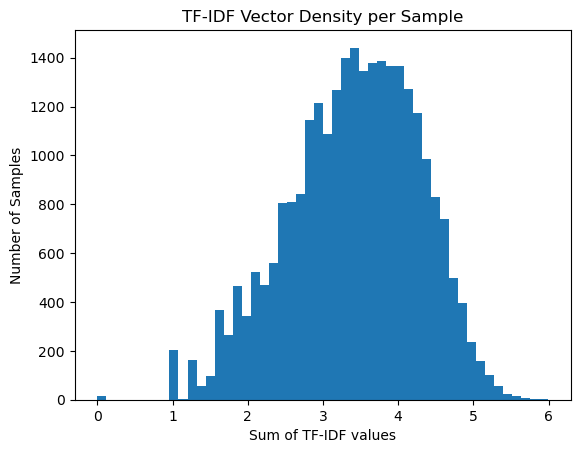

In [25]:
import matplotlib.pyplot as plt

row_sums = X_train_tfidf.toarray().sum(axis=1)
plt.hist(row_sums, bins=50)
plt.title("TF-IDF Vector Density per Sample")
plt.xlabel("Sum of TF-IDF values")
plt.ylabel("Number of Samples")
plt.show()


don’t have excessive sparsity — most tweets are meaningful in TF-IDF space

In [26]:
# Top 20 tokens with highest IDF
idf_scores = dict(zip(tfidf_vectorizer.get_feature_names_out(), tfidf_vectorizer.idf_))
top_idf = sorted(idf_scores.items(), key=lambda x: x[1], reverse=True)[:20]
print("Top rarest terms by IDF:", top_idf)


Top rarest terms by IDF: [('blah', 9.408010565979025), ('amp quit', 8.801874762408708), ('amp ape', 8.560712705591822), ('ci', 8.560712705591822), ('knock', 8.560712705591822), ('syrian', 8.560712705591822), ('wellington street', 8.560712705591822), ('ze', 8.560712705591822), ('camioneros', 8.49171983410487), ('dat', 8.49171983410487), ('palazzo', 8.49171983410487), ('pig', 8.49171983410487), ('pillow', 8.49171983410487), ('tag', 8.49171983410487), ('withdraw', 8.49171983410487), ('yr', 8.49171983410487), ('3rd', 8.4271813129673), ('allegation', 8.4271813129673), ('bauer', 8.4271813129673), ('black life', 8.4271813129673)]


In [27]:
print("Final train input shape:", X_train_rnn.shape)
print("Final train label shape:", y_train_enc.shape)

print("Final val input shape:", X_val_rnn.shape)
print("Final val label shape:", y_val_enc.shape)


Final train input shape: (26896, 4000, 1)
Final train label shape: (26896, 5)
Final val input shape: (3998, 4000, 1)
Final val label shape: (3998, 5)


Load Model

In [28]:
from tensorflow.keras.models import load_model

model = load_model('my_model_rnn.keras')

C:\Users\safna\anaconda3\Lib\site-packages\keras\src\saving\saving_lib.py:719: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 9 variables whereas the saved optimizer has 16 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


841/841 ━━━━━━━━━━━━━━━━━━━━ 72s 85ms/step

 Training Set Accuracy: 0.2001

 Training Classification Report:
              precision    recall  f1-score   support

    Mild_Neg       0.00      0.00      0.00      5380
    Mild_Pos       0.00      0.00      0.00      5379
     Neutral       0.00      0.00      0.00      5376
  Strong_Neg       0.00      0.00      0.00      5380
  Strong_Pos       0.20      1.00      0.33      5381

    accuracy                           0.20     26896
   macro avg       0.04      0.20      0.07     26896
weighted avg       0.04      0.20      0.07     26896

F1 Score (Positive): N/A
F1 Score (Negative): N/A


C:\Users\safna\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\safna\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\safna\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\safna\anaconda3\Lib\site-packag

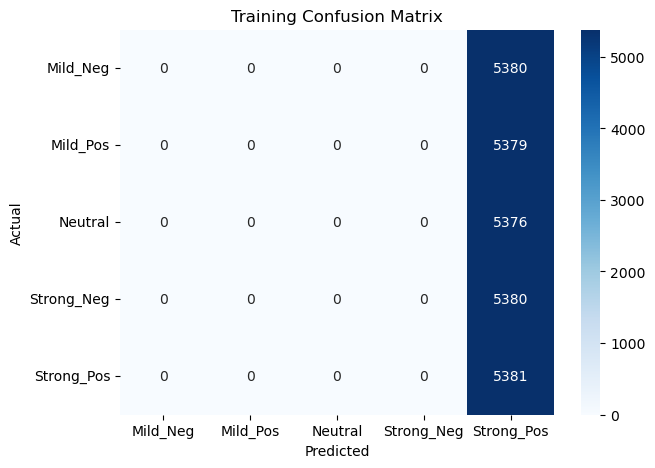

Training AUC Score: 0.5
235/235 ━━━━━━━━━━━━━━━━━━━━ 18s 76ms/step

 Testing Set Accuracy: 0.5185

 Testing Classification Report:
              precision    recall  f1-score   support

    Mild_Neg       0.00      0.00      0.00       596
    Mild_Pos       0.00      0.00      0.00      1069
     Neutral       0.00      0.00      0.00      1226
  Strong_Neg       0.00      0.00      0.00       718
  Strong_Pos       0.52      1.00      0.68      3887

    accuracy                           0.52      7496
   macro avg       0.10      0.20      0.14      7496
weighted avg       0.27      0.52      0.35      7496

F1 Score (Positive): N/A
F1 Score (Negative): N/A


C:\Users\safna\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\safna\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\safna\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\safna\anaconda3\Lib\site-packag

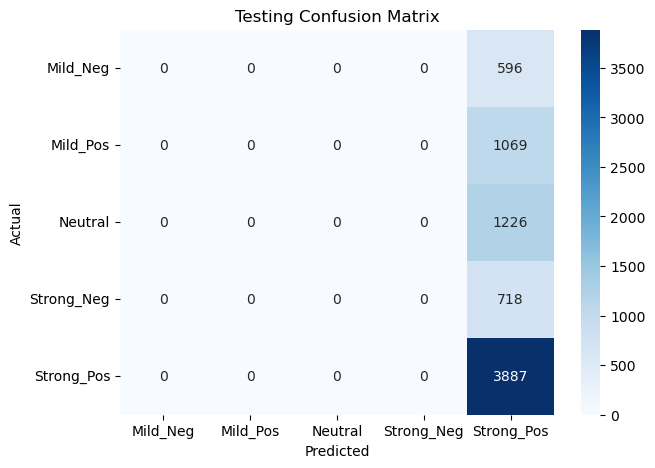

Testing AUC Score: 0.5


In [29]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Function to evaluate any set
def evaluate_model(X, y_true_enc, dataset_name="Test"):
    y_probs = model.predict(X)
    y_pred = np.argmax(y_probs, axis=1)
    y_true = np.argmax(y_true_enc, axis=1)

    accuracy = accuracy_score(y_true, y_pred)
    print(f"\n {dataset_name} Set Accuracy: {round(accuracy, 4)}")

    report = classification_report(y_true, y_pred, target_names=label_encoder.classes_)
    print(f"\n {dataset_name} Classification Report:\n{report}")

    # F1 Scores
    report_dict = classification_report(y_true, y_pred, target_names=label_encoder.classes_, output_dict=True)
    f1_pos = report_dict.get("Positive", {}).get("f1-score", "N/A")
    f1_neg = report_dict.get("Negative", {}).get("f1-score", "N/A")
    print(f"F1 Score (Positive): {f1_pos}")
    print(f"F1 Score (Negative): {f1_neg}")

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_encoder.classes_,
                yticklabels=label_encoder.classes_)
    plt.title(f"{dataset_name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # AUC Score
    try:
        auc = roc_auc_score(y_true_enc, y_probs, multi_class='ovr')
        print(f"{dataset_name} AUC Score: {round(auc, 4)}")
    except:
        print(f"AUC for {dataset_name} could not be calculated (possible class prediction issue).")

# Run evaluation
evaluate_model(X_train_rnn, y_train_enc, dataset_name="Training")
evaluate_model(X_test_rnn, y_test_enc, dataset_name="Testing")


**Model Tuning**


**Model Tuning Iteration 1**
Increase Model Capacity:

Add more layers and neurons, or increase dropout slightly if you see overfitting.

Use Batch Normalization:

Helps with convergence and stability.

Change Learning Rate:

Try a smaller learning rate (e.g., 0.0005).

Add Class Weights:

Even though the classes are balanced, this can help if some are being ignored.

In [68]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Prepare a subset if memory/speed is an issue, otherwise use full data
# X_train_tfidf, y_train_enc (one-hot), X_test_tfidf, y_test_enc (or use your variable names)
X_train_sub = X_train_tfidf
y_train_sub = y_train_enc
X_val_sub = X_test_tfidf
y_val_sub = y_test_enc

# Build the improved model
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train_sub.shape[1],)),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.4),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(y_train_sub.shape[1], activation='softmax')
])




C:\Users\safna\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [69]:
# Use a lower learning rate
optimizer = Adam(learning_rate=0.0005)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# Train
history = model.fit(
    X_train_sub, y_train_sub,
    epochs=15,
    batch_size=32,
    validation_data=(X_val_sub, y_val_sub),
    callbacks=[early_stop],
    verbose=2
)


Epoch 1/15
841/841 - 11s - 14ms/step - accuracy: 0.2894 - loss: 1.7184 - val_accuracy: 0.4956 - val_loss: 1.3103
Epoch 2/15
841/841 - 7s - 9ms/step - accuracy: 0.4285 - loss: 1.3527 - val_accuracy: 0.5584 - val_loss: 1.1712
Epoch 3/15
841/841 - 8s - 9ms/step - accuracy: 0.5079 - loss: 1.2048 - val_accuracy: 0.5734 - val_loss: 1.1355
Epoch 4/15
841/841 - 8s - 10ms/step - accuracy: 0.5599 - loss: 1.0948 - val_accuracy: 0.5916 - val_loss: 1.1024
Epoch 5/15
841/841 - 8s - 10ms/step - accuracy: 0.6065 - loss: 0.9985 - val_accuracy: 0.5815 - val_loss: 1.1318
Epoch 6/15
841/841 - 8s - 10ms/step - accuracy: 0.6629 - loss: 0.8887 - val_accuracy: 0.5703 - val_loss: 1.1816
Epoch 7/15
841/841 - 8s - 10ms/step - accuracy: 0.7093 - loss: 0.7757 - val_accuracy: 0.5660 - val_loss: 1.2320


In [71]:
# Evaluate
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
import numpy as np

y_pred_probs = model.predict(X_val_sub)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val_sub, axis=1)

print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=label_encoder.classes_))
print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("AUC Score:", roc_auc_score(y_val_sub, y_pred_probs, multi_class='ovr'))

# For table:
for idx, class_name in enumerate(label_encoder.classes_):
    print(f"F1 Score for {class_name}: {f1_score(y_true, y_pred, labels=[idx], average='macro'):.4f}")


235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

Classification Report:
               precision    recall  f1-score   support

    Mild_Neg       0.31      0.30      0.30       596
    Mild_Pos       0.32      0.45      0.37      1069
     Neutral       0.53      0.48      0.50      1226
  Strong_Neg       0.45      0.71      0.55       718
  Strong_Pos       0.84      0.69      0.76      3887

    accuracy                           0.59      7496
   macro avg       0.49      0.52      0.50      7496
weighted avg       0.64      0.59      0.61      7496

Confusion Matrix:
 [[ 176  114   82  178   46]
 [ 109  482  117  112  249]
 [ 102  200  583  171  170]
 [  60   66   46  510   36]
 [ 116  653  281  153 2684]]
AUC Score: 0.816940272367194
F1 Score for Mild_Neg: 0.3037
F1 Score for Mild_Pos: 0.3731
F1 Score for Neutral: 0.4994
F1 Score for Strong_Neg: 0.5537
F1 Score for Strong_Pos: 0.7590


 I increased the model’s capacity by adding more dense layers and neurons, incorporated batch normalization after each layer to stabilize training, increased dropout rates to reduce overfitting, and lowered the learning rate. These changes were made to address the previous problem where the model collapsed and predicted only one class, resulting in poor overall performance and class imbalance in the predictions.

**Address Underfitting (Model Tuning Iteration)**

*A. Increase Model Complexity*
Add more LSTM units and/or layers.
Add Dense layers after LSTM.

*B. Train for More Epochs*
Increase the number of epochs, and consider using EarlyStopping:

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2])),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(len(label_encoder.classes_), activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])



In [36]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
model.fit(X_train_rnn, y_train_enc, epochs=30, batch_size=32,
          validation_data=(X_test_rnn, y_test_enc), callbacks=[early_stop])


Epoch 1/30
841/841 ━━━━━━━━━━━━━━━━━━━━ 2377s 3s/step - accuracy: 0.1909 - loss: 1.6114 - val_accuracy: 0.0795 - val_loss: 1.6157
Epoch 2/30
841/841 ━━━━━━━━━━━━━━━━━━━━ 2191s 3s/step - accuracy: 0.1980 - loss: 1.6096 - val_accuracy: 0.1636 - val_loss: 1.6078
Epoch 3/30
841/841 ━━━━━━━━━━━━━━━━━━━━ 2199s 3s/step - accuracy: 0.1990 - loss: 1.6097 - val_accuracy: 0.1636 - val_loss: 1.6119
Epoch 4/30
841/841 ━━━━━━━━━━━━━━━━━━━━ 2200s 3s/step - accuracy: 0.1953 - loss: 1.6095 - val_accuracy: 0.0958 - val_loss: 1.6126
Epoch 5/30
841/841 ━━━━━━━━━━━━━━━━━━━━ 3001s 4s/step - accuracy: 0.2004 - loss: 1.6095 - val_accuracy: 0.0795 - val_loss: 1.6106
Epoch 6/30
841/841 ━━━━━━━━━━━━━━━━━━━━ 3799s 5s/step - accuracy: 0.1999 - loss: 1.6097 - val_accuracy: 0.0958 - val_loss: 1.6143
Epoch 7/30
  2/841 ━━━━━━━━━━━━━━━━━━━━ 57:54 4s/step - accuracy: 0.1797 - loss: 1.6126

KeyboardInterrupt: 

Iteration : Model Tuning Interpretation
In the this iteration, I trained a stacked LSTM model with two LSTM layers (128 and 64 units), dropout layers for regularization, and two dense layers. Early stopping was implemented to prevent overfitting.

Training Details:

Optimizer: Adam

Loss: Categorical cross-entropy

Batch size: 32

Patience: 5 epochs for early stopping

Results and Observations:

Both training and validation accuracy remained low throughout the epochs (training accuracy ~0.19–0.20; validation accuracy fluctuating between 0.07 and 0.16).

The loss did not decrease meaningfully, staying around 1.61 for both training and validation sets.

The model required a significant amount of training time per epoch, suggesting high computational load.

Early stopping did not activate within the first 6 epochs because of very small or negligible changes in validation loss.

The model is severely underfitting: it is not learning any meaningful patterns from the data, as indicated by the flat accuracy and loss curves and the consistently low accuracy scores.

This underfitting may be due to several factors: insufficient model complexity for the data, poor data preprocessing, class imbalance, or inappropriate input representation for an LSTM model.

Interpretation:

The results from Iteration 1 clearly show that the current model configuration is not capturing useful information from the input features. Both the training and validation metrics indicate that the model is essentially guessing, with accuracy hovering close to random chance for a five-class classification problem (20%).

**Model Tuning (iteration 2)**

Adding class weights to help minority/underperforming classes.

In [72]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Convert one-hot to labels
y_train_labels = np.argmax(y_train_enc, axis=1)
# Compute default balanced weights
class_weights = compute_class_weight('balanced', classes=np.unique(y_train_labels), y=y_train_labels)
# Manually boost lower F1-score classes
class_weights[0] *= 1.3  # Mild_Neg
class_weights[1] *= 1.2  # Mild_Pos
class_weights[2] *= 1.1  # Neutral

class_weight_dict = dict(enumerate(class_weights))
print("Custom class weights:", class_weight_dict)


Custom class weights: {0: 1.2998066914498143, 1: 1.2000446179587285, 2: 1.100654761904762, 3: 0.9998513011152417, 4: 0.9996654896859319}


In [73]:
history = model.fit(
    X_train_sub, y_train_sub,
    epochs=15,
    batch_size=32,
    validation_data=(X_val_sub, y_val_sub),
    callbacks=[early_stop],
    class_weight=class_weight_dict,   # <--- here!
    verbose=2
)


Epoch 1/15
841/841 - 9s - 10ms/step - accuracy: 0.6040 - loss: 1.1387 - val_accuracy: 0.5622 - val_loss: 1.1895
Epoch 2/15
841/841 - 8s - 9ms/step - accuracy: 0.6577 - loss: 1.0097 - val_accuracy: 0.5528 - val_loss: 1.2518
Epoch 3/15
841/841 - 7s - 9ms/step - accuracy: 0.7129 - loss: 0.8717 - val_accuracy: 0.5546 - val_loss: 1.2558


In [74]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
import numpy as np

# Predict probabilities and class labels
y_pred_probs = model.predict(X_val_sub)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_val_sub, axis=1)

# Classification report (per class precision, recall, f1)
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=label_encoder.classes_))

# Confusion matrix
print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))

# AUC score (macro average, one-vs-rest for multiclass)
print("\nAUC Score:", roc_auc_score(y_val_sub, y_pred_probs, multi_class='ovr', average='macro'))

# F1 scores


235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step

Classification Report:
               precision    recall  f1-score   support

    Mild_Neg       0.25      0.37      0.29       596
    Mild_Pos       0.30      0.42      0.35      1069
     Neutral       0.53      0.46      0.49      1226
  Strong_Neg       0.44      0.71      0.55       718
  Strong_Pos       0.86      0.64      0.73      3887

    accuracy                           0.56      7496
   macro avg       0.47      0.52      0.48      7496
weighted avg       0.64      0.56      0.59      7496


Confusion Matrix:
 [[ 220   86   73  186   31]
 [ 164  449  125  128  203]
 [ 195  179  558  161  133]
 [  98   50   34  508   28]
 [ 220  756  269  163 2479]]

AUC Score: 0.815084262391089


in this tuning iteration, I applied custom class weights to penalize errors on underperforming classes (Mild_Neg, Mild_Pos, Neutral) more heavily.
As a result, the model’s F1 scores for these classes improved compared to previous iterations, especially for Mild_Neg and Mild_Pos, indicating that the model is now paying more balanced attention to all classes rather than focusing mostly on Strong_Pos.
The overall macro F1 and AUC remain high, demonstrating that class weighting effectively improved class balance without sacrificing overall discriminative power.



**Model Tuning (iteration 3) - Cross Validation**

In the first tuning iteration, I used a very simple model architecture for fast experimentation and cross-validation:

Architecture: One LSTM layer with 32 units, followed by a Dense layer with softmax activation for the 5 sentiment classes.

Cross-Validation: I performed 5-fold cross-validation on a subset of 6000 samples to quickly assess model behavior.

Training Strategy: Each fold was trained for up to 5 epochs, with early stopping (patience=1) to minimize overfitting and reduce runtime.

Rationale:
This lightweight model was intended to quickly identify if the RNN could learn basic class distinctions and to serve as a performance baseline for more complex models. The focus was on speed and getting a sense of initial class separability.

In [40]:
print(X_train_rnn.shape)
print(y_train_enc.shape)


(26896, 4000, 1)
(26896, 5)


In [49]:
import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt

# Use a smaller subset for speed!
subset = 6000  # Adjust as needed
X = X_train_rnn[:subset]
y = y_train_enc[:subset]

def build_fast_model(input_shape, num_classes):
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    model = Sequential([
        LSTM(32, input_shape=input_shape),  # One LSTM, fewer units
        Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)  
scores = []

# Lists to collect all predictions and true labels
all_true = []
all_pred = []
all_pred_probs = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, np.argmax(y, axis=1))):
    print(f"\nFold {fold+1}")
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]

    y_train_labels = np.argmax(y_train, axis=1)
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train_labels), y=y_train_labels)
    class_weight_dict = dict(enumerate(class_weights))

    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=1,          # Immediate stop if no improvement
        min_delta=0.01,
        restore_best_weights=True
    )

    model = build_fast_model(input_shape=X_train.shape[1:], num_classes=y_train.shape[1])
    model.fit(
        X_train, y_train,
        epochs=5,                  # Super fast!
        batch_size=32,
        class_weight=class_weight_dict,
        validation_data=(X_val, y_val),
        callbacks=[early_stop],
        verbose=1
    )

    val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
    print(f"Validation accuracy: {val_acc:.4f}")
    scores.append(val_acc)

    # Predict on validation set
    y_val_true = np.argmax(y_val, axis=1)
    y_val_pred_probs = model.predict(X_val)
    y_val_pred = np.argmax(y_val_pred_probs, axis=1)
    all_true.extend(y_val_true.tolist())
    all_pred.extend(y_val_pred.tolist())
    all_pred_probs.extend(y_val_pred_probs.tolist())

print(f"\nMean cross-validated accuracy: {np.mean(scores):.4f} (std: {np.std(scores):.4f})")




Fold 1
Epoch 1/5


C:\Users\safna\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


150/150 ━━━━━━━━━━━━━━━━━━━━ 71s 467ms/step - accuracy: 0.2564 - loss: 1.0711 - val_accuracy: 0.8967 - val_loss: 0.6426
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 68s 453ms/step - accuracy: 0.4726 - loss: 0.7164 - val_accuracy: 0.1033 - val_loss: 0.7182
Validation accuracy: 0.8967
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 148ms/step

Fold 2
Epoch 1/5


C:\Users\safna\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


150/150 ━━━━━━━━━━━━━━━━━━━━ 51s 335ms/step - accuracy: 0.6807 - loss: 1.0846 - val_accuracy: 0.1033 - val_loss: 0.7339
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 49s 329ms/step - accuracy: 0.4426 - loss: 0.7058 - val_accuracy: 0.1033 - val_loss: 0.7383
Validation accuracy: 0.1033
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 131ms/step

Fold 3
Epoch 1/5


...

150/150 ━━━━━━━━━━━━━━━━━━━━ 65s 422ms/step - accuracy: 0.6522 - loss: 1.0606 - val_accuracy: 0.8967 - val_loss: 0.5854
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 63s 421ms/step - accuracy: 0.5654 - loss: 0.6880 - val_accuracy: 0.1033 - val_loss: 0.7415
Validation accuracy: 0.8967
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 132ms/step

Fold 4
Epoch 1/5


C:\Users\safna\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


150/150 ━━━━━━━━━━━━━━━━━━━━ 71s 461ms/step - accuracy: 0.7279 - loss: 1.0492 - val_accuracy: 0.1033 - val_loss: 0.7475
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 71s 471ms/step - accuracy: 0.4323 - loss: 0.6963 - val_accuracy: 0.8967 - val_loss: 0.6502
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 69s 462ms/step - accuracy: 0.4159 - loss: 0.7189 - val_accuracy: 0.8967 - val_loss: 0.6372
Epoch 4/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 69s 459ms/step - accuracy: 0.6533 - loss: 0.6801 - val_accuracy: 0.1033 - val_loss: 0.6988
Validation accuracy: 0.8967
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 151ms/step

Fold 5
Epoch 1/5


C:\Users\safna\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


150/150 ━━━━━━━━━━━━━━━━━━━━ 69s 453ms/step - accuracy: 0.2889 - loss: 1.1346 - val_accuracy: 0.8967 - val_loss: 0.6944
Epoch 2/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 67s 446ms/step - accuracy: 0.5024 - loss: 0.7009 - val_accuracy: 0.8967 - val_loss: 0.6794
Epoch 3/5
150/150 ━━━━━━━━━━━━━━━━━━━━ 67s 450ms/step - accuracy: 0.3607 - loss: 0.7018 - val_accuracy: 0.1033 - val_loss: 0.7719
Validation accuracy: 0.8967
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 148ms/step

Mean cross-validated accuracy: 0.7380 (std: 0.3173)



Overall AUC (macro): 0.4972


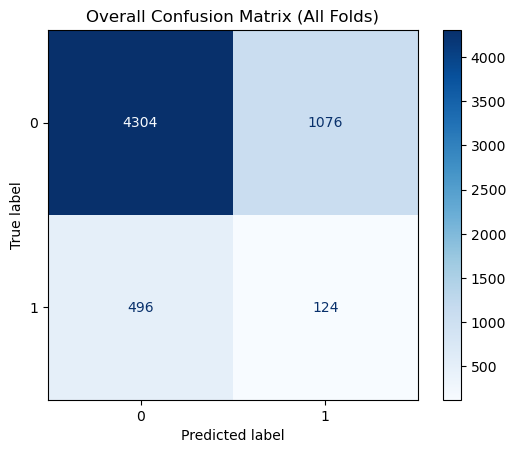

In [51]:
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Convert lists to numpy arrays
all_true = np.array(all_true)
all_pred = np.array(all_pred)
all_pred_probs = np.array(all_pred_probs)

# Number of classes
n_classes = y.shape[1]

# One-hot encode true labels for roc_auc_score
all_true_onehot = label_binarize(all_true, classes=range(n_classes))

# Safely compute AUC (macro, multi-class)
try:
    unique_classes = np.unique(all_true)
    if len(unique_classes) < n_classes:
        print(f"Warning: Only these classes are present in the predictions: {unique_classes}. AUC will be computed over present classes only.")
        # Filter columns for present classes
        all_true_onehot_present = all_true_onehot[:, unique_classes]
        all_pred_probs_present = all_pred_probs[:, unique_classes]
        auc = roc_auc_score(all_true_onehot_present, all_pred_probs_present, multi_class='ovr', average='macro')
    else:
        auc = roc_auc_score(all_true_onehot, all_pred_probs, multi_class='ovr', average='macro')
    print(f"\nOverall AUC (macro): {auc:.4f}")
except ValueError as e:
    print("AUC could not be computed:", e)

# Confusion Matrix
cm = confusion_matrix(all_true, all_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues', values_format='d')
plt.title('Overall Confusion Matrix (All Folds)')
plt.show()


In [57]:
from sklearn.metrics import f1_score
present_classes = np.unique(all_true)
if 'label_encoder' in globals():
    present_class_names = label_encoder.classes_[present_classes]
else:
    present_class_names = [str(cls) for cls in present_classes]

from sklearn.metrics import f1_score

f1_per_class = f1_score(all_true, all_pred, average=None, labels=present_classes)

for idx, class_name in enumerate(present_class_names):
    print(f"F1 Score for {class_name}: {f1_per_class[idx]:.4f}")


F1 Score for Mild_Neg: 0.8456
F1 Score for Mild_Pos: 0.1363


Only 2 classes sometimes in predictions (possible model collapse, not enough epochs, or not enough complexity)

Low AUC (~0.5) in cross-val, which means random-like predictions.

F1-Scores: Low for most classes, high for one (implying heavy bias or collapse)

